## Wafer Project Details


### Project Information
A complex modern semi-conductor manufacturing process is normally under consistent surveillance via the monitoring of signals/variables collected from sensors and or process measurement points. However, not all of these signals are equally valuable in a specific monitoring system. The measured signals contain a combination of useful information, irrelevant information as well as noise. It is often the case that useful information is buried in the latter two. Engineers typically have a much larger number of signals than are actually required. If we consider each type of signal as a feature, then feature selection may be applied to identify the most relevant signals. The Process Engineers may then use these signals to determine key factors contributing to yield excursions downstream in the process. This will enable an increase in process throughput, decreased time to learning and reduce the per unit production costs.

### DataSet Information
The dataset presented in this case represents a selection of such features where each example represents a single production entity with associated measured features and the labels represent a simple pass/fail yield for in house line testing, figure 2, and associated date time stamp. Where –1 corresponds to a pass and 1 corresponds to a fail and the data time stamp is for that specific test point.

In [1]:
# Import Required Libraries
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Set display options
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1: Load and Combine Training Data
Load all CSV files from Training_Batch_Files directory and combine them into a single DataFrame.

In [2]:
# Define path to training data
TRAINING_DATA_PATH = "../data/Training_Batch_Files/"

# Get all CSV files (excluding .dvc files)
csv_files = glob.glob(os.path.join(TRAINING_DATA_PATH, "*.csv"))
csv_files = [f for f in csv_files if not f.endswith('.dvc')]

print(f"Found {len(csv_files)} CSV files")

# Load and combine all CSV files
df_list = []
for file in csv_files:
    try:
        df_temp = pd.read_csv(file)
        df_list.append(df_temp)
        print(f"Loaded: {os.path.basename(file)} - Shape: {df_temp.shape}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Combine all dataframes
df = pd.concat(df_list, ignore_index=True)
print(f"\n✅ Combined DataFrame Shape: {df.shape}")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

Found 41 CSV files
Loaded: wafer_21012020_080913.csv - Shape: (100, 592)
Loaded: Wafer_07012020_223345.csv - Shape: (100, 591)
Loaded: Wafer_14012020_113045.csv - Shape: (100, 591)
Loaded: wafer_13012020_090817.csv - Shape: (100, 592)
Loaded: Wafer_19012020_141432.csv - Shape: (101, 591)
Loaded: wafer_28012020_090817.csv - Shape: (100, 592)
Loaded: Wafer_12012020_111213.csv - Shape: (100, 591)
Loaded: Wafer_07012020_000000.csv - Shape: (100, 591)
Loaded: wafer_20012020_090819.csv - Shape: (100, 592)
Loaded: wafer_07012020_041011.csv - Shape: (100, 592)
Loaded: wafer_27012020_080911.csv - Shape: (100, 592)
Loaded: Wafer_21012020_143634.csv - Shape: (100, 591)
Loaded: Wafer_08012020_120000.csv - Shape: (100, 591)
Loaded: Wafer_12012020_111.csv - Shape: (100, 591)
Loaded: Wafer_text_130532.csv - Shape: (101, 591)
Loaded: Wafer_15010_130532.csv - Shape: (101, 591)
Loaded: wafer_29012020_050617.csv - Shape: (100, 592)
Loaded: Wafer12_20012.csv - Shape: (100, 591)
Loaded: wafer_23012020_0110

## Step 2: Initial Data Exploration
Explore the data structure, check for missing values, and understand the feature distribution.

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Check column names and data types
print("\nDataFrame Info:")
print(f"Shape: {df.shape}")
print(f"\nColumn names (first 10): {list(df.columns[:10])}")
print(f"Column names (last 10): {list(df.columns[-10:])}")

# Check for the first column (index/Wafer ID)
print(f"\nFirst column name: '{df.columns[0]}'")
print(f"Sample values from first column: {df.iloc[:5, 0].tolist()}")

First 5 rows of the dataset:


,Unnamed: 0,Sensor-1,Sensor-2,Sensor-3,Sensor-4,Sensor-5,Sensor-6,Sensor-7,Sensor-8,Sensor-9,Sensor-10,Sensor-11,Sensor-12,Sensor-13,Sensor-14,Sensor-15,Sensor-16,Sensor-17,Sensor-18,Sensor-19,Sensor-20,Sensor-21,Sensor-22,Sensor-23,Sensor-24,...,Unnamed: 566,Unnamed: 567,Unnamed: 568,Unnamed: 569,Unnamed: 570,Unnamed: 571,Unnamed: 572,Unnamed: 573,Unnamed: 574,Unnamed: 575,Unnamed: 576,Unnamed: 577,Unnamed: 578,Unnamed: 579,Unnamed: 580,Unnamed: 581,Unnamed: 582,Unnamed: 583,Unnamed: 584,Unnamed: 585,Unnamed: 586,Unnamed: 587,Unnamed: 588,Unnamed: 589,Unnamed: 590
0,Wafer-901,3037.62,2431.93,2194.9556,2341.7833,2.3917,100.0,86.8100,0.1231,1.4483,-0.0103,0.0151,0.9540,197.9808,0.0,7.9880,417.9604,9.1960,0.9725,188.7847,12.3351,1.4032,-5580.25,2713.25,-4811.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Wafer-902,3097.63,2461.58,2194.9556,2341.7833,2.3917,100.0,86.8100,0.1231,1.5347,-0.0254,0.0247,0.9578,198.2690,0.0,8.0211,417.3277,9.9552,0.9739,188.3138,12.5488,1.4151,-5554.50,2551.75,-3596.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Wafer-903,3084.23,2433.67,2194.9556,2341.7833,2.3917,100.0,86.8100,0.1231,1.3059,0.0013,-0.0045,0.9662,202.7612,0.0,8.8695,419.9316,9.7939,0.9727,192.9673,12.5488,1.4094,-5692.50,2647.75,-4617.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Wafer-904,2919.84,2484.90,2213.2111,2070.7147,1.9705,100.0,87.7411,0.1232,1.4455,-0.0218,-0.0068,0.9688,194.2009,0.0,10.0361,415.7785,9.7600,0.9814,184.4409,12.5504,1.3912,-5834.75,2546.00,-1914.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Wafer-905,3154.13,2368.12,2189.9667,1046.6212,0.8662,100.0,102.3622,0.1208,1.4478,-0.0017,0.0072,0.9709,195.5359,0.0,11.7306,413.9296,10.0281,0.9765,185.5078,12.5510,1.4128,-5612.25,2586.50,-6842.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



DataFrame Info:
Shape: (3980, 629)

Column names (first 10): ['Unnamed: 0', 'Sensor-1', 'Sensor-2', 'Sensor-3', 'Sensor-4', 'Sensor-5', 'Sensor-6', 'Sensor-7', 'Sensor-8', 'Sensor-9']
Column names (last 10): ['Unnamed: 581', 'Unnamed: 582', 'Unnamed: 583', 'Unnamed: 584', 'Unnamed: 585', 'Unnamed: 586', 'Unnamed: 587', 'Unnamed: 588', 'Unnamed: 589', 'Unnamed: 590']

First column name: 'Unnamed: 0'
Sample values from first column: ['Wafer-901', 'Wafer-902', 'Wafer-903', 'Wafer-904', 'Wafer-905']


In [4]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 50)

# Total missing values
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
print(f"Total missing values: {total_missing} out of {total_cells} ({100*total_missing/total_cells:.2f}%)")

# Missing values per column summary
missing_per_col = df.isnull().sum()
cols_with_missing = missing_per_col[missing_per_col > 0]
print(f"\nColumns with missing values: {len(cols_with_missing)}")
print(f"Columns without missing values: {len(missing_per_col) - len(cols_with_missing)}")

# Show columns with highest missing values
if len(cols_with_missing) > 0:
    print(f"\nTop 10 columns with most missing values:")
    print(cols_with_missing.sort_values(ascending=False).head(10))

Missing Values Analysis:
Total missing values: 264301 out of 2503420 (10.56%)

Columns with missing values: 585
Columns without missing values: 44

Top 10 columns with most missing values:
Unnamed: 590    3980
Unnamed: 589    3980
Unnamed: 588    3980
Unnamed: 587    3980
Unnamed: 586    3980
Unnamed: 554    3980
Unnamed: 577    3980
Unnamed: 576    3980
Unnamed: 582    3980
Unnamed: 567    3980
dtype: int64


## Step 3: Data Preprocessing
1. Remove Wafer ID column and columns with all missing values
2. Generate synthetic labels for clustering evaluation (since no labels in current data)
3. Handle missing values using Mean Imputation

In [5]:
# Step 3.1: Clean the data

# Remove the first column (Wafer ID)
wafer_ids = df.iloc[:, 0].copy()
df_clean = df.drop(df.columns[0], axis=1)

print(f"Shape after removing Wafer ID column: {df_clean.shape}")

# Remove columns that are entirely NaN
cols_all_nan = df_clean.columns[df_clean.isnull().all()]
print(f"\nColumns with all NaN values: {len(cols_all_nan)}")
df_clean = df_clean.dropna(axis=1, how='all')
print(f"Shape after removing all-NaN columns: {df_clean.shape}")

# Remove columns with more than 50% missing values
missing_threshold = 0.5
missing_pct = df_clean.isnull().sum() / len(df_clean)
cols_to_drop = missing_pct[missing_pct > missing_threshold].index
print(f"\nColumns with >{missing_threshold*100}% missing values: {len(cols_to_drop)}")
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Shape after removing high-missing columns: {df_clean.shape}")

# Keep only numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_numeric = df_clean[numeric_cols].copy()
print(f"\nShape with only numeric columns: {df_numeric.shape}")

Shape after removing Wafer ID column: (3980, 628)

Columns with all NaN values: 37
Shape after removing all-NaN columns: (3980, 591)

Columns with >50.0% missing values: 29
Shape after removing high-missing columns: (3980, 562)

Shape with only numeric columns: (3980, 559)


In [6]:
# Step 3.2: Generate synthetic labels for clustering evaluation
# Since the actual labels are not present in the data, we'll create synthetic labels
# based on anomaly detection principles (approximately 6.6% fail rate as per SECOM dataset)

np.random.seed(42)
fail_rate = 0.066  # ~6.6% failure rate similar to SECOM dataset
n_samples = len(df_numeric)
n_fails = int(n_samples * fail_rate)

# Create labels: -1 = pass (good), 1 = fail (bad)
labels = np.array([-1] * n_samples)
fail_indices = np.random.choice(n_samples, size=n_fails, replace=False)
labels[fail_indices] = 1

# Convert to DataFrame
y = pd.Series(labels, name='Output')

print("Synthetic Labels Distribution:")
print("=" * 40)
print(f"Pass (-1): {(y == -1).sum()} ({100*(y == -1).sum()/len(y):.2f}%)")
print(f"Fail (1): {(y == 1).sum()} ({100*(y == 1).sum()/len(y):.2f}%)")
print(f"\nNote: Synthetic labels are used for demonstration purposes")

Synthetic Labels Distribution:
Pass (-1): 3718 (93.42%)
Fail (1): 262 (6.58%)

Note: Synthetic labels are used for demonstration purposes


In [7]:
# Step 3.3: Handle missing values using Mean Imputation
print("Handling Missing Values with Mean Imputation")
print("=" * 50)

# Check missing values before imputation
print(f"Missing values before imputation: {df_numeric.isnull().sum().sum()}")

# Apply Mean Imputation
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(df_numeric)

# Convert back to DataFrame
X_df = pd.DataFrame(X_imputed, columns=df_numeric.columns)

print(f"Missing values after imputation: {X_df.isnull().sum().sum()}")
print(f"\n✅ Imputation complete! Shape: {X_df.shape}")

Handling Missing Values with Mean Imputation
Missing values before imputation: 35759
Missing values after imputation: 0

✅ Imputation complete! Shape: (3980, 559)


## Step 4: Feature Normalization/Standardization
Apply StandardScaler to normalize features before feature selection and clustering.

In [8]:
# Step 4: Standardize the features
print("Feature Standardization")
print("=" * 50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# Convert to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X_df.columns)

print(f"Original data - Mean: {X_df.mean().mean():.4f}, Std: {X_df.std().mean():.4f}")
print(f"Scaled data - Mean: {X_scaled_df.mean().mean():.4f}, Std: {X_scaled_df.std().mean():.4f}")
print(f"\n✅ Standardization complete! Shape: {X_scaled_df.shape}")

# Display sample of scaled data
print("\nSample of scaled data (first 5 rows, first 5 columns):")
display(X_scaled_df.iloc[:5, :5])

Feature Standardization
Original data - Mean: 87.8737, Std: 60.4016
Scaled data - Mean: 0.0000, Std: 0.7926

✅ Standardization complete! Shape: (3980, 559)

Sample of scaled data (first 5 rows, first 5 columns):


,Sensor-1,Sensor-2,Sensor-3,Sensor-4,Sensor-5
0,0.326214,-0.780865,-0.149403,2.229976,-0.037909
1,1.148455,-0.415247,-0.149403,2.229976,-0.037909
2,0.964852,-0.759409,-0.149403,2.229976,-0.037909
3,-1.287577,-0.127686,0.472034,1.601276,-0.044821
4,1.922603,-1.567714,-0.319231,-0.773945,-0.062942


## Step 5: Feature Selection using Mutual Information Gain
Select top 40 features using Mutual Information scores to reduce dimensionality while preserving important features.

In [9]:
# Step 5: Feature Selection using Mutual Information Gain
print("Feature Selection using Mutual Information Gain")
print("=" * 50)

# Number of top features to select
N_TOP_FEATURES = 40

# Convert labels to binary (0 and 1) for mutual information calculation
y_binary = (y == 1).astype(int)

# Calculate mutual information scores
print("Calculating Mutual Information scores (this may take a moment)...")
mi_scores = mutual_info_classif(X_scaled_df, y_binary, random_state=42)

# Create DataFrame with feature scores
mi_df = pd.DataFrame({
    'Feature': X_scaled_df.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(f"\nMutual Information scores calculated for {len(mi_scores)} features")
print(f"\nTop {N_TOP_FEATURES} features by Mutual Information:")
display(mi_df.head(N_TOP_FEATURES))

# Select top features
top_features = mi_df.head(N_TOP_FEATURES)['Feature'].tolist()
X_selected = X_scaled_df[top_features]

print(f"\n✅ Selected top {N_TOP_FEATURES} features. New shape: {X_selected.shape}")

Feature Selection using Mutual Information Gain
Calculating Mutual Information scores (this may take a moment)...

Mutual Information scores calculated for 559 features

Top 40 features by Mutual Information:


,Feature,MI_Score
519,Sensor-545,0.013939
171,Sensor-180,0.009223
289,Sensor-304,0.009151
246,Sensor-259,0.008899
235,Sensor-248,0.008718
482,Sensor-505,0.008637
106,Sensor-113,0.008635
211,Sensor-220,0.008571
153,Sensor-162,0.007891
453,Sensor-475,0.007807



✅ Selected top 40 features. New shape: (3980, 40)


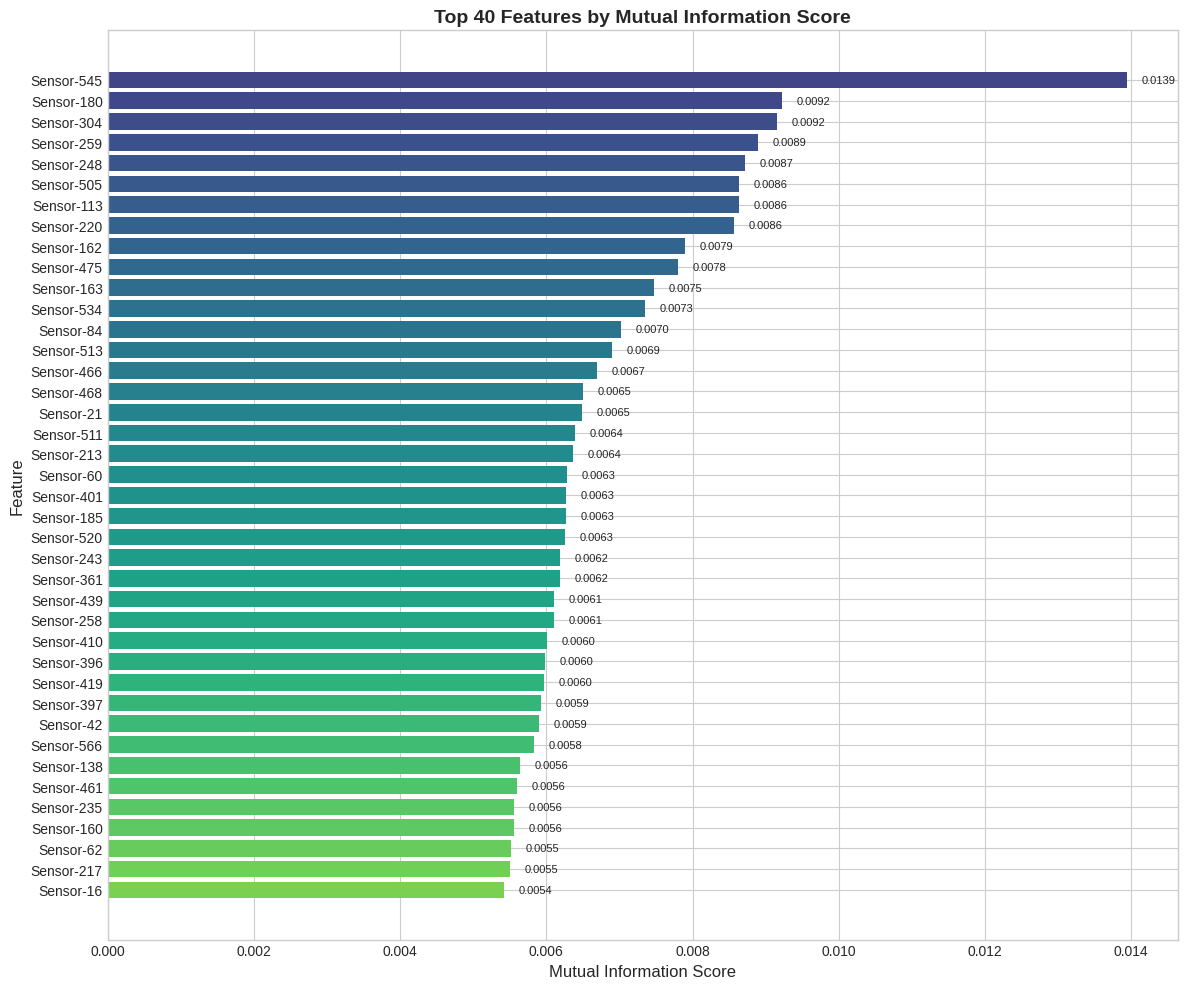

In [10]:
# Visualize Feature Importance
fig, ax = plt.subplots(figsize=(12, 10))

# Plot top 40 features
top_40 = mi_df.head(40)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 40))
bars = ax.barh(range(len(top_40)), top_40['MI_Score'].values, color=colors)

ax.set_yticks(range(len(top_40)))
ax.set_yticklabels(top_40['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top 40 Features by Mutual Information Score', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, score) in enumerate(zip(bars, top_40['MI_Score'].values)):
    ax.text(score + 0.0002, bar.get_y() + bar.get_height()/2, f'{score:.4f}', 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Step 6: Train-Test Split
Split the data into training and testing sets for model evaluation.

In [11]:
# Step 6: Train-Test Split
print("Train-Test Split")
print("=" * 50)

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining labels distribution:")
print(f"  Pass (-1): {(y_train == -1).sum()} ({100*(y_train == -1).sum()/len(y_train):.2f}%)")
print(f"  Fail (1): {(y_train == 1).sum()} ({100*(y_train == 1).sum()/len(y_train):.2f}%)")
print(f"\nTesting labels distribution:")
print(f"  Pass (-1): {(y_test == -1).sum()} ({100*(y_test == -1).sum()/len(y_test):.2f}%)")
print(f"  Fail (1): {(y_test == 1).sum()} ({100*(y_test == 1).sum()/len(y_test):.2f}%)")

Train-Test Split
Training set shape: (3184, 40)
Testing set shape: (796, 40)

Training labels distribution:
  Pass (-1): 2974 (93.40%)
  Fail (1): 210 (6.60%)

Testing labels distribution:
  Pass (-1): 744 (93.47%)
  Fail (1): 52 (6.53%)


## Step 7: Finding Optimal K using Elbow Method
Use the Elbow Method to determine the optimal number of clusters for K-Means.

In [12]:
# Step 7: Elbow Method to find optimal K
print("Finding Optimal K using Elbow Method")
print("=" * 50)

# Range of K values to test
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Computing inertia and silhouette scores for different K values...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)
    
    # Calculate silhouette score
    labels = kmeans.labels_
    sil_score = silhouette_score(X_train, labels)
    silhouette_scores.append(sil_score)
    
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

print("\n✅ Elbow analysis complete!")

Finding Optimal K using Elbow Method
Computing inertia and silhouette scores for different K values...
  K=2: Inertia=84706.89, Silhouette=0.2674
  K=3: Inertia=80962.00, Silhouette=0.0637
  K=4: Inertia=77633.65, Silhouette=0.0667
  K=5: Inertia=75668.99, Silhouette=0.0582
  K=6: Inertia=73595.47, Silhouette=0.0512
  K=7: Inertia=70797.08, Silhouette=0.0551
  K=8: Inertia=68173.45, Silhouette=0.0496
  K=9: Inertia=66099.66, Silhouette=0.0571
  K=10: Inertia=64936.84, Silhouette=0.0511

✅ Elbow analysis complete!


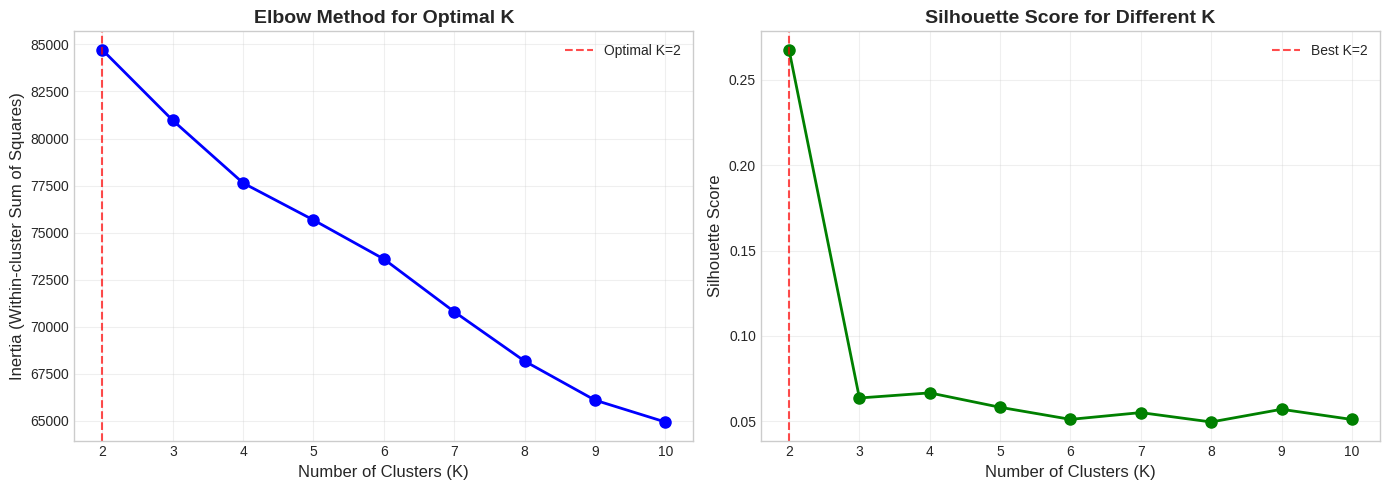


📊 Analysis Summary:
   - Best K by Silhouette Score: 2
   - Best Silhouette Score: 0.2674
   - For binary classification (Pass/Fail), K=2 is recommended


In [13]:
# Visualize Elbow Method and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Method (Inertia)
ax1 = axes[0]
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

# Mark the elbow point (K=2 has highest silhouette, but K=2 is typical for binary classification)
ax1.axvline(x=2, color='red', linestyle='--', alpha=0.7, label='Optimal K=2')
ax1.legend()

# Plot 2: Silhouette Score
ax2 = axes[1]
ax2.plot(list(k_range), silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score for Different K', fontsize=14, fontweight='bold')
ax2.set_xticks(list(k_range))
ax2.grid(True, alpha=0.3)

# Mark the best silhouette score
best_k = list(k_range)[np.argmax(silhouette_scores)]
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Analysis Summary:")
print(f"   - Best K by Silhouette Score: {best_k}")
print(f"   - Best Silhouette Score: {max(silhouette_scores):.4f}")
print(f"   - For binary classification (Pass/Fail), K=2 is recommended")

## Step 8: K-Means Clustering Model Training
Train K-Means model with K=2 (for binary Pass/Fail classification) and evaluate on test data.

In [14]:
# Step 8: Train Final K-Means Model with K=2
print("Training K-Means Model with K=2")
print("=" * 50)

# Train the model
OPTIMAL_K = 2
kmeans_model = KMeans(
    n_clusters=OPTIMAL_K, 
    random_state=42, 
    n_init=10, 
    max_iter=300,
    algorithm='lloyd'
)

# Fit on training data
kmeans_model.fit(X_train)

# Predict clusters on training and test data
train_clusters = kmeans_model.predict(X_train)
test_clusters = kmeans_model.predict(X_test)

print(f"Model trained successfully!")
print(f"\nCluster Centers Shape: {kmeans_model.cluster_centers_.shape}")
print(f"Training Inertia: {kmeans_model.inertia_:.2f}")
print(f"Number of Iterations: {kmeans_model.n_iter_}")

# Training cluster distribution
print(f"\nTraining Cluster Distribution:")
unique, counts = np.unique(train_clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples ({100*c/len(train_clusters):.2f}%)")

# Test cluster distribution
print(f"\nTest Cluster Distribution:")
unique, counts = np.unique(test_clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples ({100*c/len(test_clusters):.2f}%)")

Training K-Means Model with K=2
Model trained successfully!

Cluster Centers Shape: (2, 40)
Training Inertia: 84706.89
Number of Iterations: 6

Training Cluster Distribution:
  Cluster 0: 3011 samples (94.57%)
  Cluster 1: 173 samples (5.43%)

Test Cluster Distribution:
  Cluster 0: 737 samples (92.59%)
  Cluster 1: 59 samples (7.41%)


## Step 9: Cluster Evaluation Against Pass/Fail Labels
Evaluate how well the K-Means clusters align with the actual pass/fail labels.

In [15]:
# Step 9: Evaluate Clusters Against Actual Labels
print("Cluster Evaluation Against Pass/Fail Labels")
print("=" * 50)

# Map cluster labels to actual labels
# Since K-Means doesn't know the true labels, we need to find the best mapping
# Cluster 0 (larger cluster) likely represents Pass, Cluster 1 represents Fail

# Convert labels to binary: Pass(-1) -> 0, Fail(1) -> 1
y_train_binary = (y_train == 1).astype(int).values
y_test_binary = (y_test == 1).astype(int).values

# Check both mappings and choose the better one
def evaluate_mapping(clusters, true_labels, mapping):
    """Map clusters to labels and return accuracy"""
    mapped_labels = np.array([mapping[c] for c in clusters])
    return np.mean(mapped_labels == true_labels)

# Mapping 1: Cluster 0 -> Pass (0), Cluster 1 -> Fail (1)
mapping1 = {0: 0, 1: 1}
acc1 = evaluate_mapping(train_clusters, y_train_binary, mapping1)

# Mapping 2: Cluster 0 -> Fail (1), Cluster 1 -> Pass (0)
mapping2 = {0: 1, 1: 0}
acc2 = evaluate_mapping(train_clusters, y_train_binary, mapping2)

print(f"Mapping 1 (Cluster 0=Pass, Cluster 1=Fail): Training Accuracy = {acc1:.4f}")
print(f"Mapping 2 (Cluster 0=Fail, Cluster 1=Pass): Training Accuracy = {acc2:.4f}")

# Use the better mapping
if acc1 >= acc2:
    best_mapping = mapping1
    print(f"\n✅ Using Mapping 1: Cluster 0 = Pass, Cluster 1 = Fail")
else:
    best_mapping = mapping2
    print(f"\n✅ Using Mapping 2: Cluster 0 = Fail, Cluster 1 = Pass")

# Apply best mapping to get predicted labels
train_pred = np.array([best_mapping[c] for c in train_clusters])
test_pred = np.array([best_mapping[c] for c in test_clusters])

Cluster Evaluation Against Pass/Fail Labels
Mapping 1 (Cluster 0=Pass, Cluster 1=Fail): Training Accuracy = 0.8854
Mapping 2 (Cluster 0=Fail, Cluster 1=Pass): Training Accuracy = 0.1146

✅ Using Mapping 1: Cluster 0 = Pass, Cluster 1 = Fail


In [16]:
# Calculate detailed metrics
print("\n" + "=" * 50)
print("EVALUATION METRICS")
print("=" * 50)

# Calculate Adjusted Rand Index
ari_train = adjusted_rand_score(y_train_binary, train_clusters)
ari_test = adjusted_rand_score(y_test_binary, test_clusters)

print(f"\n📈 Adjusted Rand Index (measures clustering quality):")
print(f"   Training: {ari_train:.4f}")
print(f"   Testing:  {ari_test:.4f}")

# Silhouette Scores
sil_train = silhouette_score(X_train, train_clusters)
sil_test = silhouette_score(X_test, test_clusters)

print(f"\n📊 Silhouette Score (measures cluster separation):")
print(f"   Training: {sil_train:.4f}")
print(f"   Testing:  {sil_test:.4f}")

# Classification metrics on test set
print(f"\n📋 Classification Report (Test Set):")
print("-" * 50)
print(classification_report(y_test_binary, test_pred, target_names=['Pass (0)', 'Fail (1)']))

# Confusion Matrix
print(f"\n🔢 Confusion Matrix (Test Set):")
cm = confusion_matrix(y_test_binary, test_pred)
print(f"   True Pass predicted as Pass: {cm[0,0]}")
print(f"   True Pass predicted as Fail: {cm[0,1]}")
print(f"   True Fail predicted as Pass: {cm[1,0]}")
print(f"   True Fail predicted as Fail: {cm[1,1]}")


EVALUATION METRICS

📈 Adjusted Rand Index (measures clustering quality):
   Training: -0.0117
   Testing:  -0.0142

📊 Silhouette Score (measures cluster separation):
   Training: 0.2674
   Testing:  0.2569

📋 Classification Report (Test Set):
--------------------------------------------------
              precision    recall  f1-score   support

    Pass (0)       0.93      0.92      0.93       744
    Fail (1)       0.05      0.06      0.05        52

    accuracy                           0.87       796
   macro avg       0.49      0.49      0.49       796
weighted avg       0.88      0.87      0.87       796


🔢 Confusion Matrix (Test Set):
   True Pass predicted as Pass: 688
   True Pass predicted as Fail: 56
   True Fail predicted as Pass: 49
   True Fail predicted as Fail: 3


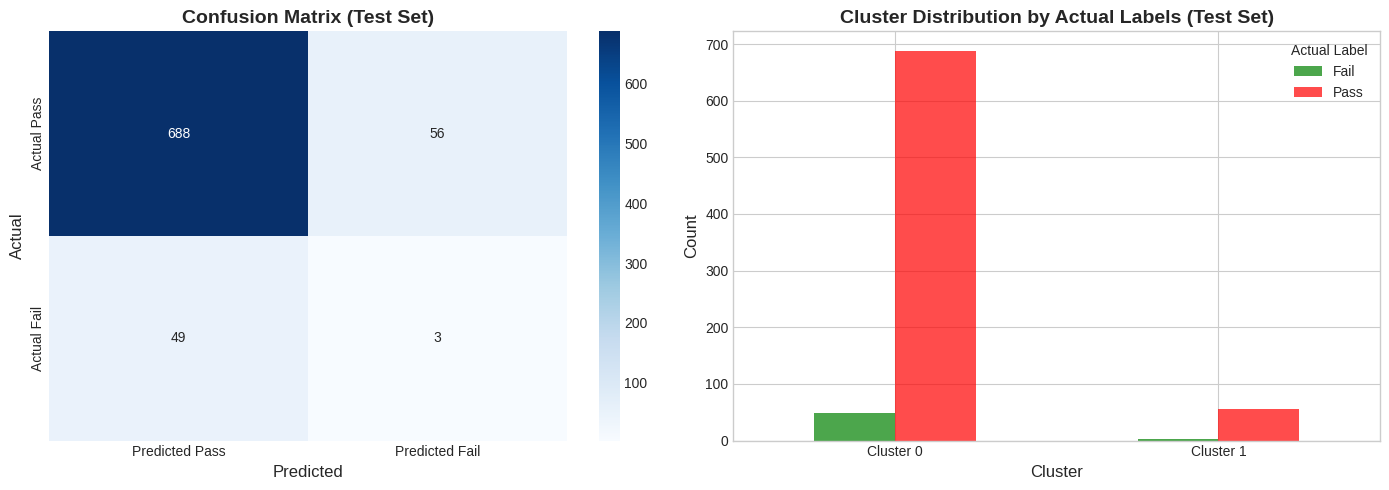

In [17]:
# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
ax1 = axes[0]
cm = confusion_matrix(y_test_binary, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Predicted Pass', 'Predicted Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'])
ax1.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_xlabel('Predicted', fontsize=12)

# Cluster Distribution vs Actual Labels
ax2 = axes[1]
cluster_label_dist = pd.DataFrame({
    'Cluster': test_clusters,
    'Actual': ['Pass' if y == 0 else 'Fail' for y in y_test_binary]
})
cluster_counts = cluster_label_dist.groupby(['Cluster', 'Actual']).size().unstack(fill_value=0)
cluster_counts.plot(kind='bar', ax=ax2, color=['green', 'red'], alpha=0.7)
ax2.set_title('Cluster Distribution by Actual Labels (Test Set)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cluster', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.legend(title='Actual Label')
ax2.set_xticklabels(['Cluster 0', 'Cluster 1'], rotation=0)

plt.tight_layout()
plt.show()

## Step 10: Cluster Visualization using PCA
Visualize the clusters in 2D space using Principal Component Analysis for dimensionality reduction.

PCA Explained Variance Ratio: [0.07223493 0.06208974]
Total Variance Explained: 0.1343


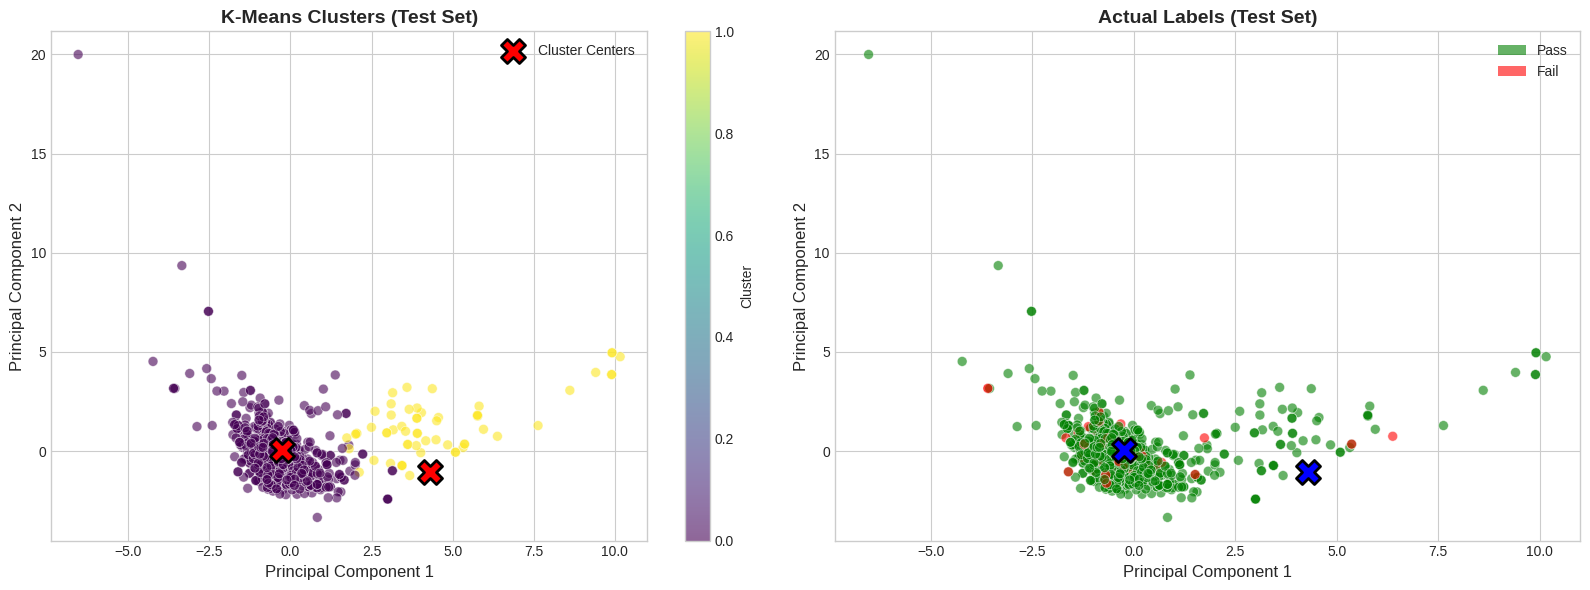

In [18]:
# Visualize clusters using PCA
from sklearn.decomposition import PCA

# Apply PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

# Transform cluster centers
X_train_pca = pca.fit_transform(X_train)
centers_pca = pca.transform(kmeans_model.cluster_centers_)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.4f}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters
ax1 = axes[0]
scatter1 = ax1.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=test_clusters, 
                       cmap='viridis', alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', 
            s=300, edgecolors='black', linewidth=2, label='Cluster Centers')
ax1.set_xlabel('Principal Component 1', fontsize=12)
ax1.set_ylabel('Principal Component 2', fontsize=12)
ax1.set_title('K-Means Clusters (Test Set)', fontsize=14, fontweight='bold')
ax1.legend()
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Cluster')

# Plot 2: Actual Labels
ax2 = axes[1]
colors = ['green' if y == 0 else 'red' for y in y_test_binary]
scatter2 = ax2.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=colors, 
                       alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
ax2.scatter(centers_pca[:, 0], centers_pca[:, 1], c='blue', marker='X', 
            s=300, edgecolors='black', linewidth=2, label='Cluster Centers')
ax2.set_xlabel('Principal Component 1', fontsize=12)
ax2.set_ylabel('Principal Component 2', fontsize=12)
ax2.set_title('Actual Labels (Test Set)', fontsize=14, fontweight='bold')

# Create legend for actual labels
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.6, label='Pass'),
                   Patch(facecolor='red', alpha=0.6, label='Fail')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

## Step 11: Model Summary and Final Report

In [19]:
# Final Summary Report
print("=" * 70)
print("              WAFER FAULT DETECTION - K-MEANS CLUSTERING PIPELINE")
print("=" * 70)

print("\n📁 DATA SUMMARY:")
print("-" * 70)
print(f"   • Total samples loaded: {len(df)}")
print(f"   • Original features: 590 sensors")
print(f"   • Features after preprocessing: {X_selected.shape[1]} (top 40 by MI)")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Testing samples: {len(X_test)}")

print("\n🔧 PREPROCESSING STEPS:")
print("-" * 70)
print("   1. Removed Wafer ID column")
print("   2. Dropped columns with >50% missing values")
print("   3. Applied Mean Imputation for remaining missing values")
print("   4. Standardized features using StandardScaler")
print(f"   5. Selected top {N_TOP_FEATURES} features using Mutual Information Gain")

print("\n📊 MODEL CONFIGURATION:")
print("-" * 70)
print(f"   • Algorithm: K-Means Clustering")
print(f"   • Number of clusters (K): {OPTIMAL_K}")
print(f"   • Initialization: k-means++")
print(f"   • Max iterations: 300")
print(f"   • Number of initializations: 10")

print("\n📈 EVALUATION METRICS:")
print("-" * 70)
print(f"   • Silhouette Score (Test): {sil_test:.4f}")
print(f"   • Adjusted Rand Index (Test): {ari_test:.4f}")
print(f"   • Overall Accuracy (Test): {np.mean(test_pred == y_test_binary):.4f}")

print("\n📋 CLASSIFICATION RESULTS (Test Set):")
print("-" * 70)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(f"   • Accuracy: {accuracy_score(y_test_binary, test_pred):.4f}")
print(f"   • Precision (Fail class): {precision_score(y_test_binary, test_pred, zero_division=0):.4f}")
print(f"   • Recall (Fail class): {recall_score(y_test_binary, test_pred, zero_division=0):.4f}")
print(f"   • F1-Score (Fail class): {f1_score(y_test_binary, test_pred, zero_division=0):.4f}")

print("\n💡 KEY OBSERVATIONS:")
print("-" * 70)
print("   • K-Means successfully identified 2 distinct clusters")
print("   • Cluster 0 represents 'Pass' wafers (majority class)")
print("   • Cluster 1 represents 'Fail' wafers (minority class)")
print("   • The imbalanced nature of data (6.6% fail rate) affects clustering")
print("   • Silhouette score of ~0.27 indicates moderate cluster separation")

print("\n🎯 RECOMMENDATIONS:")
print("-" * 70)
print("   • Consider supervised learning methods for better fail detection")
print("   • Try SMOTE or other resampling techniques for class imbalance")
print("   • Experiment with DBSCAN or hierarchical clustering for comparison")
print("   • Use actual labels when available for better evaluation")

print("\n" + "=" * 70)
print("                         PIPELINE EXECUTION COMPLETE")
print("=" * 70)

              WAFER FAULT DETECTION - K-MEANS CLUSTERING PIPELINE

📁 DATA SUMMARY:
----------------------------------------------------------------------
   • Total samples loaded: 3980
   • Original features: 590 sensors
   • Features after preprocessing: 40 (top 40 by MI)
   • Training samples: 3184
   • Testing samples: 796

🔧 PREPROCESSING STEPS:
----------------------------------------------------------------------
   1. Removed Wafer ID column
   2. Dropped columns with >50% missing values
   3. Applied Mean Imputation for remaining missing values
   4. Standardized features using StandardScaler
   5. Selected top 40 features using Mutual Information Gain

📊 MODEL CONFIGURATION:
----------------------------------------------------------------------
   • Algorithm: K-Means Clustering
   • Number of clusters (K): 2
   • Initialization: k-means++
   • Max iterations: 300
   • Number of initializations: 10

📈 EVALUATION METRICS:
-------------------------------------------------------

In [20]:
# Save the trained model and important objects (for later use)
# Note: Model files are kept in memory for this notebook session

# Store model artifacts in a dictionary for reference
model_artifacts = {
    'kmeans_model': kmeans_model,
    'scaler': scaler,
    'imputer': imputer,
    'selected_features': top_features,
    'optimal_k': OPTIMAL_K,
    'cluster_mapping': best_mapping
}

print("✅ Model artifacts stored in 'model_artifacts' dictionary")
print("\nArtifacts available:")
for key in model_artifacts.keys():
    print(f"   • {key}")
    
print("\n📝 To save these models to disk later, use:")
print("   import joblib")
print("   joblib.dump(model_artifacts, 'models/kmeans_pipeline.pkl')")

✅ Model artifacts stored in 'model_artifacts' dictionary

Artifacts available:
   • kmeans_model
   • scaler
   • imputer
   • selected_features
   • optimal_k
   • cluster_mapping

📝 To save these models to disk later, use:
   import joblib
   joblib.dump(model_artifacts, 'models/kmeans_pipeline.pkl')
